In [2]:
!pip install -q tensorflow
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, Dense, Flatten, Dropout
from tensorflow.keras import Model
import numpy as np
import matplotlib.pyplot as plt

In [3]:

print("GPU disponível?", tf.config.list_physical_devices('GPU'))


GPU disponível? [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
fashion_mnist = tf.keras.datasets.fashion_mnist
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()


print("valores de pixel antes da normalização")
print(x_train[0].min(), x_train[0].max())

x_train, x_test = x_train / 255.0, x_test / 255.0 #normaliza os valores intensidade dos pixels 0.0 - 1.0

print("valores de pixel depois da normalização")
print(x_train[0].min(), x_train[0].max())

print(x_train.shape) # 60000 imagens
print(x_test.shape) # 10000 imagens

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
valores de pixel antes da normalização
0 255
valores de pixel depois da normalização
0.0 1.0
(60000, 28, 28)
(10000, 28, 28)


In [5]:
#a convolução espera dimensão para cor, como é escala de cinza adiciona-se superficialmente

x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

print(x_train.shape)
print(x_test.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


In [6]:
# numero de classes
K = len(set(y_train))
print("Número de classes: ", K)

Número de classes:  10


In [7]:
#buildando o modelo mas agora usando functional API

i = Input(shape=x_train[0].shape) # 60000 imagens na entrada

# "x" é a variavel em que sera feita a construção da rede, 32 filtros 3x3,
# com passo (stride) de 2 pixels, ou seja, com sobreposição, pra limiar de ativação vai ser usado ReLu
# e essa primeira camada de convolução "x" é aplicada sobre o tensor "i"
x = Conv2D(32, (3, 3), strides=2, activation='relu')(i)
print("output primeira camada", x)

#igual a anterior mas com 64 fitros, é interessante observar que a sobreposição causada por um stride=2 em um filtro 3x3
# pode dispensar o uso de pooling já que ocorre a redução da dimensionalidade por 2
x = Conv2D(64, (3, 3), strides=2, activation='relu')(x)
print("output segunda camada", x)

# igual a anterior mas com 128 kernels
x = Conv2D(128, (3, 3), strides=2, activation='relu')(x)
print("output terceira camada", x)

#aplica-se um dropout
x = Flatten()(x) # vetoriza-se antes de entrar na ANN
print("output flatten", x)

x = Dropout(0.2)(x) # dropout de 20%
print("entrada ANN", x)
 # x é um vetor de 512 após o flattening e o dropout


x = Dense(512, activation='relu')(x)
x = Dropout(0.2)(x)
x = Dense(K, activation='softmax')(x)

model = Model(i, x)


output primeira camada <KerasTensor shape=(None, 13, 13, 32), dtype=float32, sparse=False, name=keras_tensor_1>
output segunda camada <KerasTensor shape=(None, 6, 6, 64), dtype=float32, sparse=False, name=keras_tensor_2>
output terceira camada <KerasTensor shape=(None, 2, 2, 128), dtype=float32, sparse=False, name=keras_tensor_3>
output flatten <KerasTensor shape=(None, 512), dtype=float32, sparse=False, name=keras_tensor_4>
entrada ANN <KerasTensor shape=(None, 512), dtype=float32, sparse=False, name=keras_tensor_5>


In [8]:
#compilando e fitting

r = model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

In [10]:
r = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.7484 - loss: 0.6932 - val_accuracy: 0.8458 - val_loss: 0.4131
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8576 - loss: 0.3766 - val_accuracy: 0.8686 - val_loss: 0.3558
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.8815 - loss: 0.3157 - val_accuracy: 0.8804 - val_loss: 0.3239
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8956 - loss: 0.2770 - val_accuracy: 0.8821 - val_loss: 0.3071
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9061 - loss: 0.2510 - val_accuracy: 0.8905 - val_loss: 0.2898


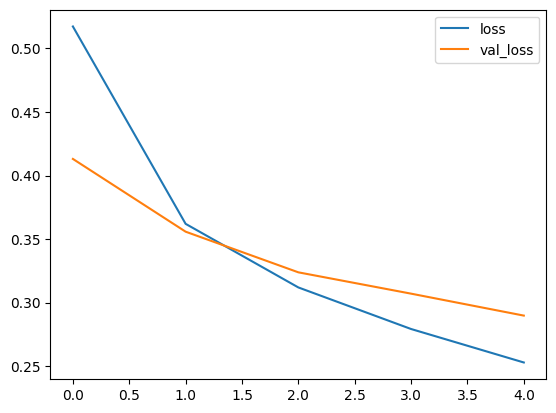

In [11]:
plt.plot(r.history['loss'], label='loss')
plt.plot(r.history['val_loss'], label='val_loss')
plt.legend()

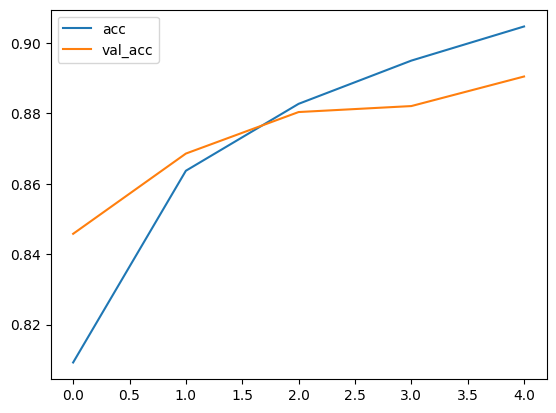

In [12]:
plt.plot(r.history['accuracy'], label='acc')
plt.plot(r.history['val_accuracy'], label='val_acc')
plt.legend()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
confusion matrix, without normalization
[[822   2  28  10   2   1 129   0   6   0]
 [  1 973   1  17   2   0   4   0   2   0]
 [ 17   0 881   9  32   0  59   0   2   0]
 [ 12   4  15 918  20   0  27   0   4   0]
 [  1   1 112  39 771   0  74   0   2   0]
 [  1   0   0   2   0 974   0  13   1   9]
 [103   0  89  31  91   0 674   0  12   0]
 [  0   0   0   0   0  11   0 964   0  25]
 [  1   0   9   3   4   2   7   2 972   0]
 [  1   0   0   0   0   5   0  36   2 956]]


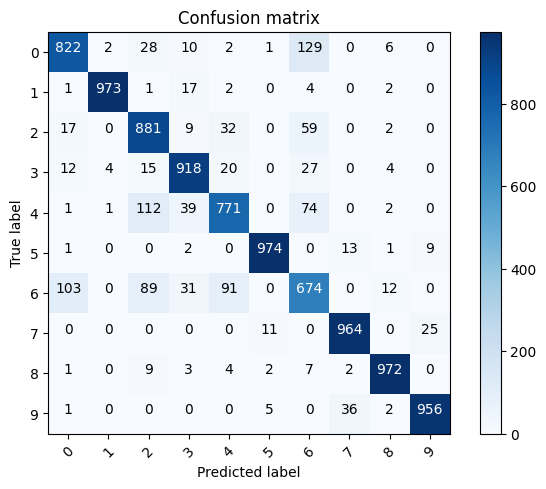

In [16]:
from sklearn.metrics import confusion_matrix
import itertools

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):

    if normalize:
      cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
      print("Normalized confusion matrix")
    else:
      print('confusion matrix, without normalization')

    print(cm)

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
      plt.text(j, i, format(cm[i, j], fmt),
               horizontalalignment="center",
               color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

p_test = model.predict(x_test).argmax(axis=1)
cm = confusion_matrix(y_test, p_test)
plot_confusion_matrix(cm, list(range(10)))


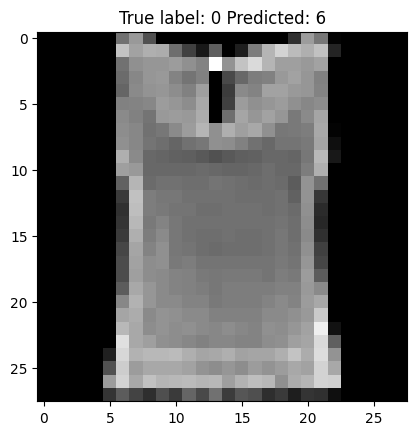

In [18]:
misclassified_idx = np.where(p_test != y_test)[0]
i = np.random.choice(misclassified_idx)
plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
plt.title("True label: %s Predicted: %s" % (y_test[i], p_test[i]));